# Attention as Manifold Learning

This notebook explores using self-attention mechanisms for manifold learning and dimensionality reduction. We compare attention-based embeddings with traditional manifold learning methods from scikit-learn.

## Hypothesis
The attention matrix learned through self-reconstruction can be interpreted as a similarity/distance matrix that captures the intrinsic manifold structure of the data, similar to what manifold learning algorithms discover.


In [37]:
# Import required libraries
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn import datasets, manifold
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import copy
import math
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection
def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Metal Performance Shaders) device")
    else:
        device = torch.device('cpu')
        print("Using CPU device")
    return device

device = get_device()


Using MPS (Metal Performance Shaders) device


## Feed-Forward MLP and Simple Self-Attention Model for Manifold Learning


In [38]:
class FeedForwardMLP(nn.Module):
    """
    Two-layer feed-forward MLP with GELU activation and dropout.
    """
    def __init__(self, input_dim, output_dim, mlp_expansion=2, dropout=0.0):
        """
        Args:
            input_dim: input feature dimension
            output_dim: output feature dimension
            mlp_expansion: expansion factor for hidden layer
            dropout: dropout rate
        """
        super().__init__()
        hidden_dim = int(input_dim * mlp_expansion)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        return self.net(x)

class SimpleSelfAttention(nn.Module):
    """
    Simple self-attention model for manifold learning.
    Learns attention weights through self-reconstruction.
    Supports both linear and MLP projections for Q/K.
    Supports attention dropout for regularization.
    """
    def __init__(self, d_model, n_hidden, use_attention_scores=False, use_mlp_projections=False):
        super().__init__()
        # Q, K projections - can use MLP for nonlinear transformations
        if use_mlp_projections:
            self.W_Q = FeedForwardMLP(d_model, n_hidden, mlp_expansion=2, dropout=0.0)
            self.W_K = FeedForwardMLP(d_model, n_hidden, mlp_expansion=2, dropout=0.0)
        else:
            self.W_Q = nn.Linear(d_model, n_hidden, bias=False)  # Query projection
            self.W_K = nn.Linear(d_model, n_hidden, bias=False)  # Key projection
        self.W_V = nn.Identity()  # Value projection (identity)
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores
        self.use_mlp_projections = use_mlp_projections
    
    def forward(self, x, attn_mask=None, attn_dropout=0.0):
        """
        Args:
            x: (batch, n_points, d_model) input points
            attn_mask: optional mask tensor of shape (batch, n_points, n_points)
            attn_dropout: float between 0 and 1, fraction of neurons to randomly mask per row
        Returns:
            Dictionary with output, attn_weights, attn_scores, attn_mask
        """
        batch_size, n_points, d_model = x.shape
        device = x.device
        
        # Compute Q, K, V
        Q = self.W_Q(x)  # (batch, n_points, n_hidden)
        K = self.W_K(x)  # (batch, n_points, n_hidden)
        V = self.W_V(x)  # (batch, n_points, d_model)
        
        # Create base diagonal mask (1 everywhere except diagonal)
        if attn_mask is None:
            attn_mask = (1 - torch.eye(n_points, device=device)).unsqueeze(0).expand(batch_size, -1, -1)
        
        # Apply attention dropout if specified
        if attn_dropout > 0:
            # Calculate number of neurons to mask per row
            n_mask = int(attn_dropout * n_points)
            if n_mask > 0:
                # Clone mask to avoid modifying the original
                attn_mask = attn_mask.clone()
                
                # Efficient vectorized approach: generate random column indices for each row
                # Shape: (batch_size, n_points, n_mask) - random columns to mask for each row
                random_col_indices = torch.randint(0, n_points, (batch_size, n_points, n_mask), device=device)
                
                # Create dropout mask and use scatter_ for efficient assignment
                dropout_mask = torch.zeros((batch_size, n_points, n_points), device=device)
                # scatter_ along dim=2 (column dimension) to set mask positions
                dropout_mask.scatter_(2, random_col_indices, 1)
                
                # Apply dropout mask to attention mask
                attn_mask = attn_mask * (1 - dropout_mask)
        
        # Compute attention scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / (self.n_hidden**0.5)
        
        # Apply mask
        inf_masked_scores = scores.masked_fill(attn_mask == 0, float("-inf"))
        attn_weights = torch.softmax(inf_masked_scores, dim=-1)
        attn_scores = scores.masked_fill(attn_mask == 0, 0.0)
        
        # Reconstruct
        if self.use_attention_scores:
            reconstructed = torch.bmm(attn_scores, V)
        else:
            reconstructed = torch.bmm(attn_weights, V)
        
        return {
            'output': reconstructed,
            'attn_weights': attn_weights,
            'attn_scores': attn_scores,
            'attn_mask': attn_mask
        }


## Dataset Class for Manifold Learning


In [39]:
class ManifoldDataset(Dataset):
    """
    Dataset that emits chunks (windows) of the underlying manifold data.
    A "sample" is defined as a chunk of shape (seq_len, D). If seq_len is
    None, the chunk is the entire dataset. num_chunks determines how many
    chunks this dataset will provide.
    """
    def __init__(self, X, seq_len=None, stride=1, num_chunks=1, randomize=True):
        """
        Args:
            X: (N_points, D) numpy array of data points
            seq_len: length of each chunk (None => entire dataset)
            stride: stride between chunk start positions when seq_len is set
            num_chunks: number of chunks to materialize
            randomize: sample chunk start indices randomly (default True)
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.N_points, self.D = self.X.shape
        self.chunk_len = seq_len if seq_len is not None else self.N_points
        self.chunk_len = max(1, min(self.chunk_len, self.N_points))
        self.stride = max(1, stride)
        self.num_chunks = max(1, num_chunks)
        self.randomize = randomize
        
        # All valid start indices for windows
        if self.chunk_len >= self.N_points:
            possible_starts = [0]
        else:
            max_start = max(0, self.N_points - self.chunk_len)
            possible_starts = list(range(0, max_start + 1, self.stride))
            if not possible_starts:
                possible_starts = [0]
        self.possible_starts = possible_starts
        
        # Sample start indices for each chunk
        if self.randomize:
            replace = len(self.possible_starts) < self.num_chunks
            choices = np.random.choice(self.possible_starts, size=self.num_chunks, replace=replace)
            self.chunk_start_indices = choices.tolist()
        else:
            repeats = math.ceil(self.num_chunks / len(self.possible_starts))
            tiled = (self.possible_starts * repeats)[:self.num_chunks]
            self.chunk_start_indices = tiled
    
    def __len__(self):
        return self.num_chunks
    
    def __getitem__(self, idx):
        start_idx = self.chunk_start_indices[idx]
        end_idx = min(start_idx + self.chunk_len, self.N_points)
        return self.X[start_idx:end_idx].clone()


## Training Function


In [40]:
def train_attention_manifold(model, dataset, config, device):
    """
    Train attention model for manifold learning.
    
    Args:
        model: SimpleSelfAttention model
        dataset: ManifoldDataset
        config: Configuration dictionary with 'loss_type' ('l1' or 'mse'), 'attn_dropout', etc.
        device: torch device
    """
    # Select loss function based on config
    loss_type = config.get('loss_type', 'mse').lower()
    if loss_type == 'l1':
        criterion = nn.L1Loss()
    elif loss_type == 'mse':
        criterion = nn.MSELoss()
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}. Must be 'l1' or 'mse'")
    
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'])
    
    loader = DataLoader(dataset, batch_size=config['batch_size'], shuffle=True)
    
    history = {'losses': []}
    
    # Get attention dropout from config
    attn_dropout = config.get('attn_dropout', 0.0)
    
    for epoch in range(config['num_epochs']):
        epoch_losses = []
        for batch in loader:
            batch = batch.to(device)
            
            # Forward pass with attention dropout
            out = model(batch, attn_dropout=attn_dropout)
            recon = out['output']
            
            # Reconstruction loss
            loss = criterion(recon, batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        avg_loss = np.mean(epoch_losses)
        history['losses'].append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{config['num_epochs']}, Loss: {avg_loss:.6f}")
    
    return history


## Extract Attention-Based Embeddings

We'll use the attention matrix as a similarity matrix and convert it to distances for MDS, following the approach from the main notebook.


In [41]:
def extract_attention_embedding(model, X, device, use_attention_scores=False, n_samples=100, attn_dropout=0.0):
    """
    Extract attention matrix and convert to 2D embedding using MDS.
    
    Args:
        model: Trained SimpleSelfAttention model
        X: (N_points, D) numpy array of data points
        device: torch device
        use_attention_scores: If True, use raw scores instead of weights
        n_samples: Number of forward passes to average over
        attn_dropout: Attention dropout rate (0.0 for deterministic extraction)
    
    Returns:
        embedding: (N_points, 2) numpy array of 2D coordinates
        attention_matrix: (N_points, N_points) averaged attention matrix
    """
    model.eval()
    attention_matrices = []
    
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)  # Add batch dim
    
    with torch.no_grad():
        for _ in range(n_samples):
            out = model(X_tensor, attn_dropout=attn_dropout)
            if use_attention_scores:
                attn = out['attn_scores'].cpu().numpy()[0]  # Remove batch dim
            else:
                attn = out['attn_weights'].cpu().numpy()[0]
            attention_matrices.append(attn)
    
    # Average attention matrices
    attention_matrix = np.mean(attention_matrices, axis=0)
    
    # Convert attention (similarity) to distance matrix
    # Restore diagonal to 1.0 (self-similarity)
    np.fill_diagonal(attention_matrix, 1.0)
    
    # Symmetrize
    attention_similarity = np.clip(0.5 * (attention_matrix + attention_matrix.T), 0, 1)
    
    # Convert similarity to distance using information distance (same as main notebook)
    eps = 1e-9
    attention_distance = np.sqrt(np.maximum(0.0, -np.log(attention_similarity + eps)))
    
    # Apply MDS to get 2D embedding
    mds = manifold.MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress=False)
    embedding = mds.fit_transform(attention_distance)
    
    return embedding, attention_matrix


## Generate Datasets

We'll use the same datasets as sklearn's manifold learning examples (see [sklearn documentation](https://scikit-learn.org/stable/auto_examples/manifold/plot_compare_methods.html)).


In [43]:
# Generate S-curve dataset
n_samples = 1500
S_points_full, S_color_full = datasets.make_s_curve(n_samples, random_state=0)

# Split into train/test (50/50)
from sklearn.model_selection import train_test_split
S_points_train, S_points_test, S_color_train, S_color_test = train_test_split(
    S_points_full, S_color_full, test_size=0.5, random_state=42
)

print(f"S-curve dataset: {S_points_full.shape}")
print(f"Train set: {S_points_train.shape}, Test set: {S_points_test.shape}")
print(f"Color range: [{S_color_full.min():.2f}, {S_color_full.max():.2f}]")


S-curve dataset: (1500, 3)
Train set: (750, 3), Test set: (750, 3)
Color range: [-4.71, 4.71]


## Visualization Functions


In [44]:
# Import for 3D plotting
import mpl_toolkits.mplot3d  # noqa: F401

def plot_3d(points, color, title, ax=None):
    """Plot 3D data."""
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
    x, y, z = points.T
    ax.scatter(x, y, z, c=color, s=50, alpha=0.8, cmap=plt.cm.Spectral)
    ax.set_title(title, size=14, fontweight='bold')
    return ax

def plot_2d(points, color, title, ax=None):
    """Plot 2D embedding."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(points[:, 0], points[:, 1], c=color, s=50, alpha=0.8, cmap=plt.cm.Spectral)
    ax.set_title(title, size=14, fontweight='bold')
    ax.set_aspect('equal')
    return ax


## Train Attention Model on S-Curve


In [46]:
# Configuration
CONFIG = {
    'd_model': 3,  # S-curve is 3D
    'n_hidden': 64,
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 100,
    'use_attention_scores': False,
    'use_mlp_projections': False,  # Will test both linear and MLP
    'seq_len': 500,  # None = full data, or int for windowing
    'stride': 1,  # Only used if seq_len is not None
    'num_chunks': 1,  # Number of chunks (samples) to draw per epoch
    'loss_type': 'mse',  # 'mse' or 'l1' for reconstruction loss
    'attn_dropout': 0.05  # Dropout for attention mask beyond diagonal (self) masking
}

# Create train dataset (using train split)
scurve_dataset = ManifoldDataset(
    S_points_train,
    seq_len=CONFIG.get('seq_len', None),
    stride=CONFIG.get('stride', 1),
    num_chunks=CONFIG.get('num_chunks', 1)
)

print(f"Train dataset created: {len(scurve_dataset)} chunks")
if CONFIG.get('seq_len') is not None:
    print(f"  Chunk length: {CONFIG['seq_len']}, Stride: {CONFIG['stride']}")
else:
    print(f"  Chunk length: full data ({S_points_train.shape[0]} points)")


Train dataset created: 1 chunks
  Chunk length: 500, Stride: 1


## Compare with Traditional Manifold Learning Methods

We'll apply various manifold learning methods from scikit-learn and compare them with our attention-based approach.


In [47]:
# Apply various manifold learning methods
# For induction methods (PCA, LLE, Isomap) we fit on train and transform test
# For transductive methods (MDS, Spectral, t-SNE) with only fit_transform, fit_transform on TEST set
n_neighbors = 12
n_components = 2

methods = {}

# PCA (baseline linear method) - fit on train, transform test
pca = PCA(n_components=n_components, random_state=42)
pca.fit(S_points_train)
methods['PCA'] = pca.transform(S_points_test)

# Locally Linear Embedding (LLE) - fit on train, transform test
lle = manifold.LocallyLinearEmbedding(
    n_neighbors=n_neighbors, 
    n_components=n_components, 
    random_state=42
)
lle.fit(S_points_train)
methods['LLE'] = lle.transform(S_points_test)

# Isomap - fit on train, transform test
isomap = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components)
isomap.fit(S_points_train)
methods['Isomap'] = isomap.transform(S_points_test)

# MDS - purely transductive: fit_transform on TEST set
mds = manifold.MDS(n_components=n_components, random_state=42, normalized_stress=False)
mds_test = mds.fit_transform(S_points_test)
methods['MDS'] = mds_test  # Using test embedding (MDS limitation)

# Spectral Embedding - purely transductive: fit_transform on TEST set
spectral = manifold.SpectralEmbedding(
    n_components=n_components,
    n_neighbors=n_neighbors,
    random_state=42
)
spectral_test = spectral.fit_transform(S_points_test)
methods['Spectral'] = spectral_test  # Using test embedding (SpectralEmbedding limitation)

# t-SNE - purely transductive: fit_transform on TEST set
tsne = manifold.TSNE(
    n_components=n_components,
    perplexity=30,
    random_state=42,
    init='random'
)
tsne_test = tsne.fit_transform(S_points_test)
methods['t-SNE'] = tsne_test  # Using test embedding (t-SNE limitation)

# Note: Attention-based methods (Linear and MLP) will be added after training in the next section
# They will also be evaluated on test set

print(f"Applied {len(methods)} sklearn methods (inductive use test transform, transductive fit_transform on test):")
for name, embedding in methods.items():
    print(f"  {name}: {embedding.shape}")
print("\n(Attention methods will be added after training in the next section)")


Applied 6 sklearn methods (inductive use test transform, transductive fit_transform on test):
  PCA: (750, 2)
  LLE: (750, 2)
  Isomap: (750, 2)
  MDS: (750, 2)
  Spectral: (750, 2)
  t-SNE: (750, 2)

(Attention methods will be added after training in the next section)


## Compare Linear vs MLP Projections

Let's test both linear and nonlinear (MLP) projections to see if MLP better approximates nonlinear manifold learning methods.


In [48]:
# Test both linear and MLP projections
print("="*80)
print("Testing Linear vs MLP Projections")
print("="*80)

# Linear projections
print("\n1. Training with LINEAR projections...")
CONFIG_LINEAR = CONFIG.copy()
CONFIG_LINEAR['use_mlp_projections'] = False

model_linear = SimpleSelfAttention(
    d_model=CONFIG_LINEAR['d_model'],
    n_hidden=CONFIG_LINEAR['n_hidden'],
    use_attention_scores=CONFIG_LINEAR['use_attention_scores'],
    use_mlp_projections=CONFIG_LINEAR['use_mlp_projections']
).to(device)
linear_init_state = copy.deepcopy(model_linear.state_dict())

print(f"Linear model parameters: {sum(p.numel() for p in model_linear.parameters()):,}")
history_linear = train_attention_manifold(model_linear, scurve_dataset, CONFIG_LINEAR, device)
# Extract embedding on TEST set (trained)
embedding_linear_trained, _ = extract_attention_embedding(
    model_linear, S_points_test, device, 
    use_attention_scores=CONFIG_LINEAR['use_attention_scores'],
    n_samples=100
)
# Evaluate the untrained model (same initialization, no gradient steps)
model_linear_untrained = SimpleSelfAttention(
    d_model=CONFIG_LINEAR['d_model'],
    n_hidden=CONFIG_LINEAR['n_hidden'],
    use_attention_scores=CONFIG_LINEAR['use_attention_scores'],
    use_mlp_projections=CONFIG_LINEAR['use_mlp_projections']
).to(device)
model_linear_untrained.load_state_dict(linear_init_state)
embedding_linear_untrained, _ = extract_attention_embedding(
    model_linear_untrained, S_points_test, device,
    use_attention_scores=CONFIG_LINEAR['use_attention_scores'],
    n_samples=100
)

# MLP projections
print("\n2. Training with MLP (nonlinear) projections...")
CONFIG_MLP = CONFIG.copy()
CONFIG_MLP['use_mlp_projections'] = True

model_mlp = SimpleSelfAttention(
    d_model=CONFIG_MLP['d_model'],
    n_hidden=CONFIG_MLP['n_hidden'],
    use_attention_scores=CONFIG_MLP['use_attention_scores'],
    use_mlp_projections=CONFIG_MLP['use_mlp_projections']
).to(device)
mlp_init_state = copy.deepcopy(model_mlp.state_dict())

print(f"MLP model parameters: {sum(p.numel() for p in model_mlp.parameters()):,}")
history_mlp = train_attention_manifold(model_mlp, scurve_dataset, CONFIG_MLP, device)
# Extract embedding on TEST set (trained)
embedding_mlp_trained, _ = extract_attention_embedding(
    model_mlp, S_points_test, device,
    use_attention_scores=CONFIG_MLP['use_attention_scores'],
    n_samples=100
)
# Evaluate the untrained MLP model
model_mlp_untrained = SimpleSelfAttention(
    d_model=CONFIG_MLP['d_model'],
    n_hidden=CONFIG_MLP['n_hidden'],
    use_attention_scores=CONFIG_MLP['use_attention_scores'],
    use_mlp_projections=CONFIG_MLP['use_mlp_projections']
).to(device)
model_mlp_untrained.load_state_dict(mlp_init_state)
embedding_mlp_untrained, _ = extract_attention_embedding(
    model_mlp_untrained, S_points_test, device,
    use_attention_scores=CONFIG_MLP['use_attention_scores'],
    n_samples=100
)

# Add to methods dictionary (trained vs untrained)
methods['Attention (Linear - Untrained)'] = embedding_linear_untrained
methods['Attention (Linear - Trained)'] = embedding_linear_trained
methods['Attention (MLP - Untrained)'] = embedding_mlp_untrained
methods['Attention (MLP - Trained)'] = embedding_mlp_trained

print(f"\nSummary:")
print(f"  Linear model parameters: {sum(p.numel() for p in model_linear.parameters()):,}")
print(f"  MLP model parameters: {sum(p.numel() for p in model_mlp.parameters()):,}")
print(f"  Total methods for comparison: {len(methods)}")


Testing Linear vs MLP Projections

1. Training with LINEAR projections...
Linear model parameters: 384
Epoch 10/100, Loss: 1.140313
Epoch 20/100, Loss: 0.992611
Epoch 30/100, Loss: 0.856348
Epoch 40/100, Loss: 0.738682
Epoch 50/100, Loss: 0.639585
Epoch 60/100, Loss: 0.556483
Epoch 70/100, Loss: 0.490892
Epoch 80/100, Loss: 0.436680
Epoch 90/100, Loss: 0.393995
Epoch 100/100, Loss: 0.358742

2. Training with MLP (nonlinear) projections...
MLP model parameters: 944
Epoch 10/100, Loss: 0.931458
Epoch 20/100, Loss: 0.900511
Epoch 30/100, Loss: 0.867710
Epoch 40/100, Loss: 0.827861
Epoch 50/100, Loss: 0.781731
Epoch 60/100, Loss: 0.724555
Epoch 70/100, Loss: 0.657393
Epoch 80/100, Loss: 0.585263
Epoch 90/100, Loss: 0.513152
Epoch 100/100, Loss: 0.449538

Summary:
  Linear model parameters: 384
  MLP model parameters: 944
  Total methods for comparison: 10


## Visualize Comparisons


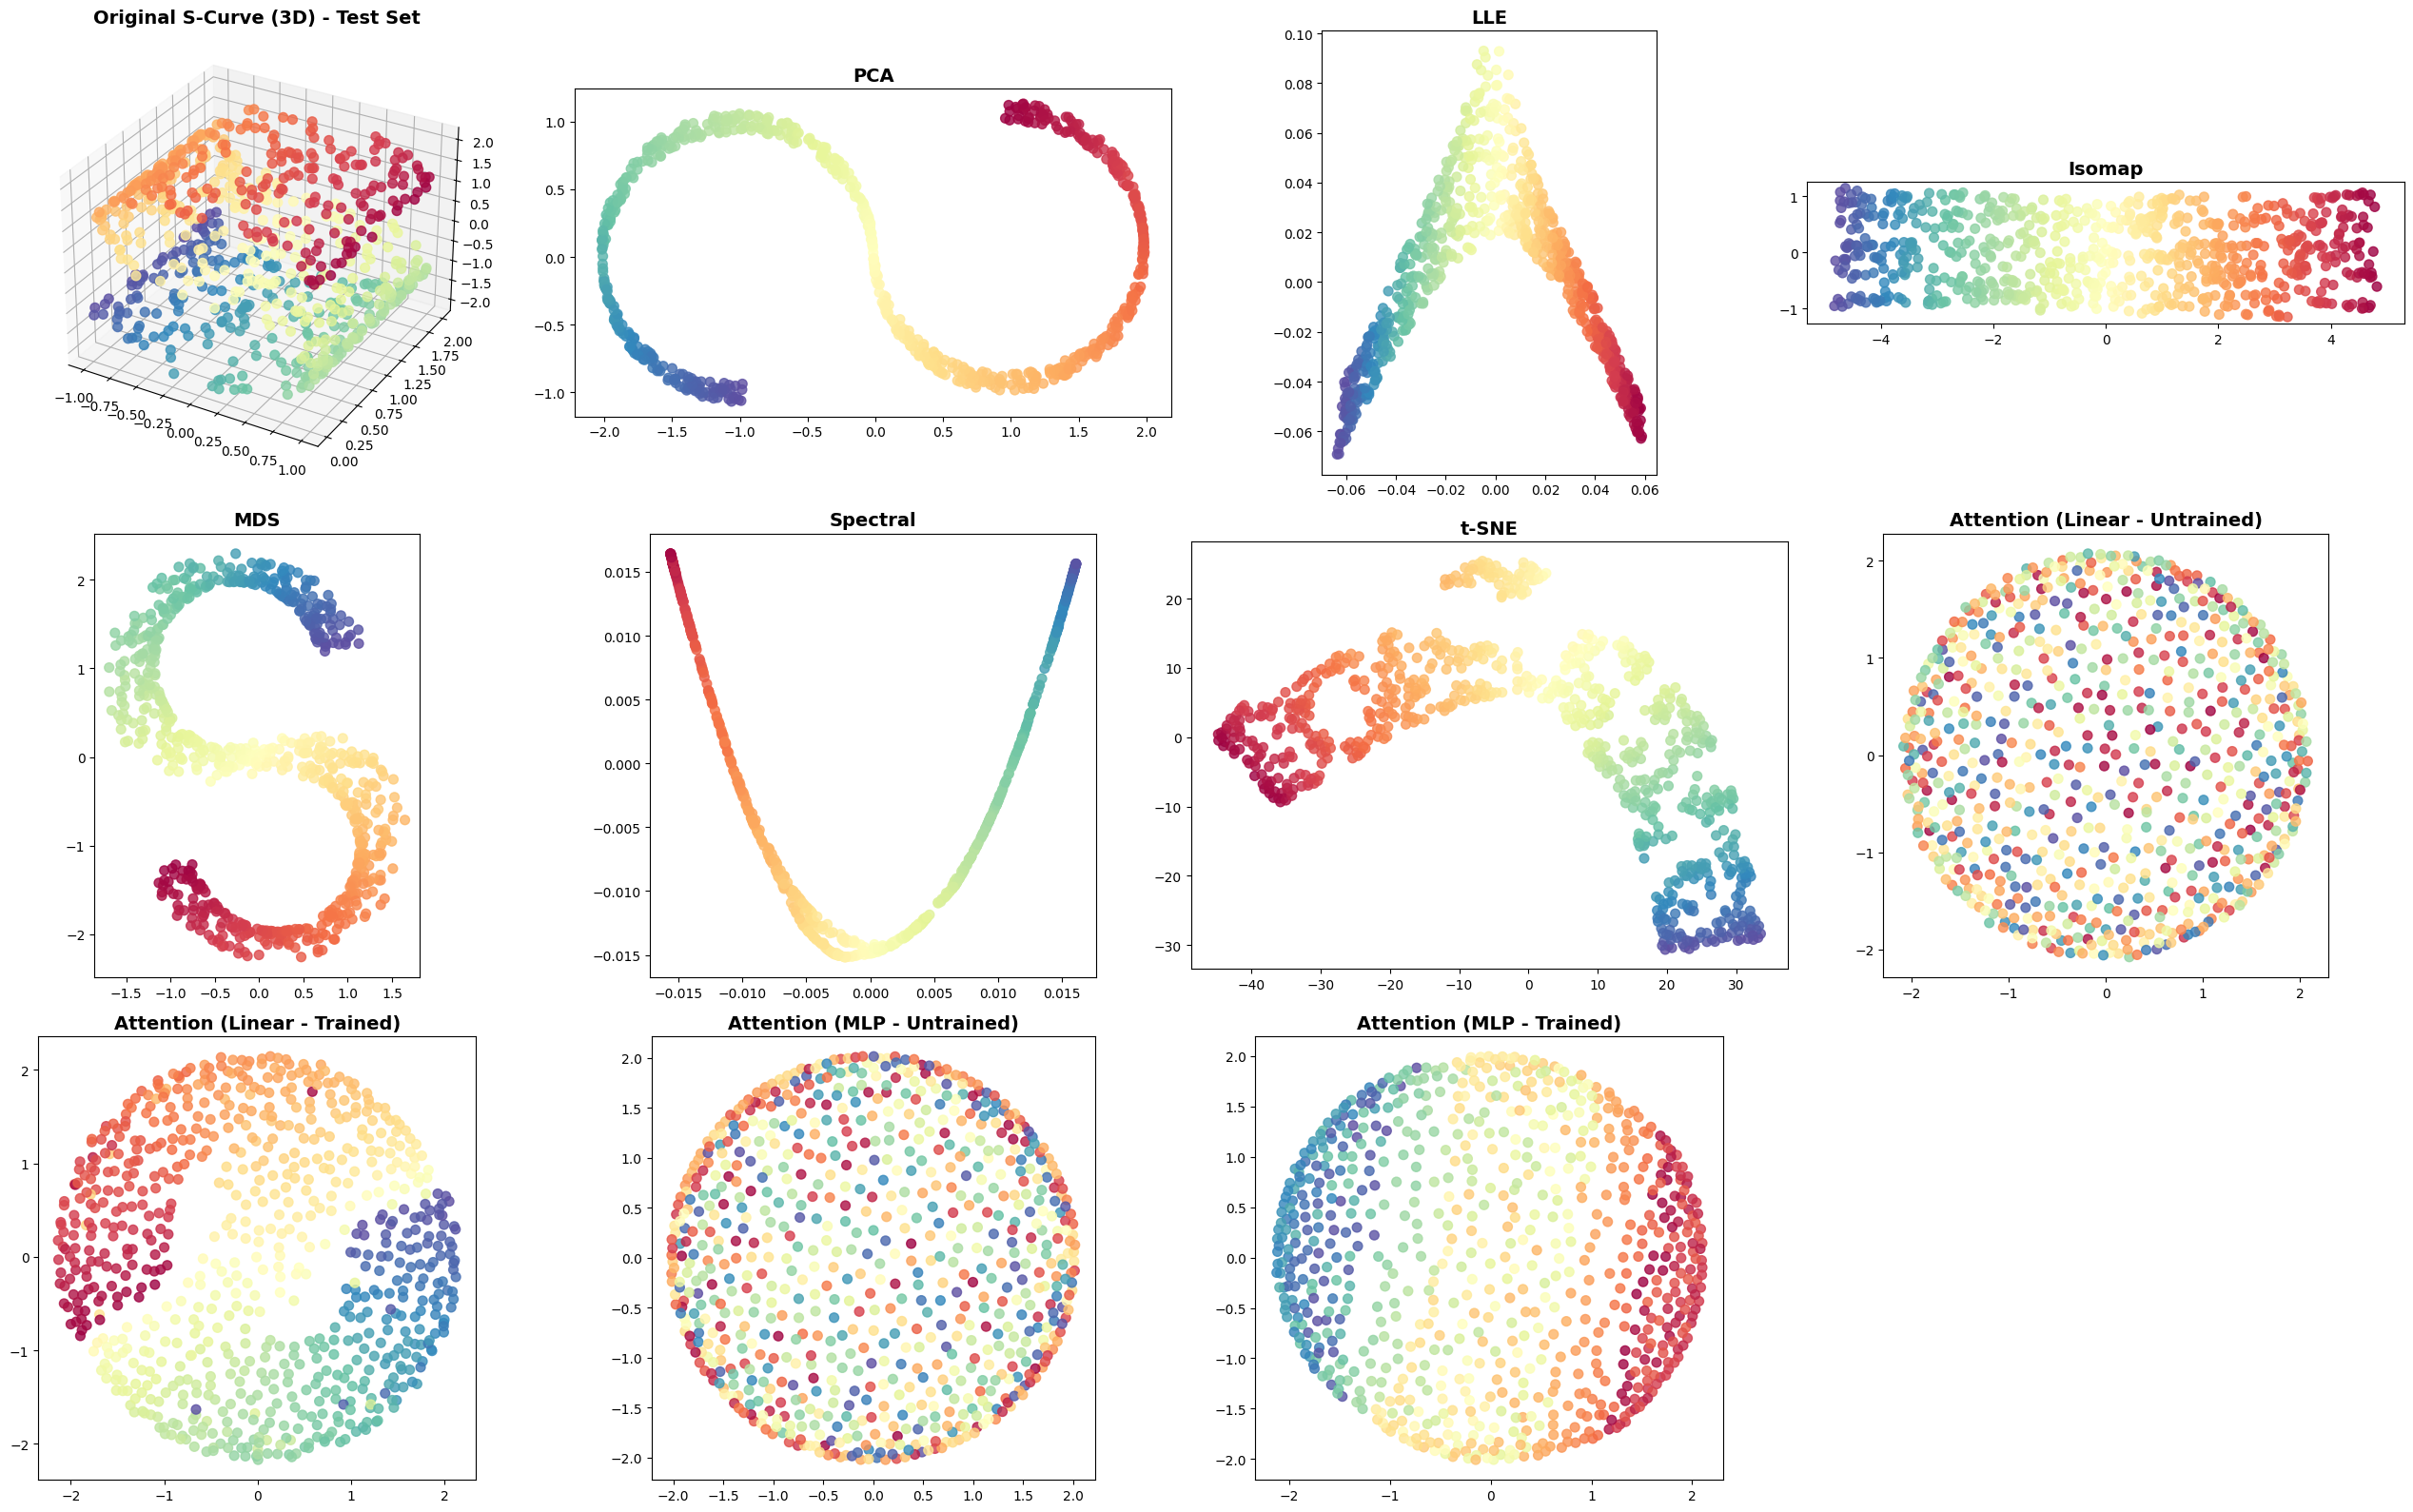

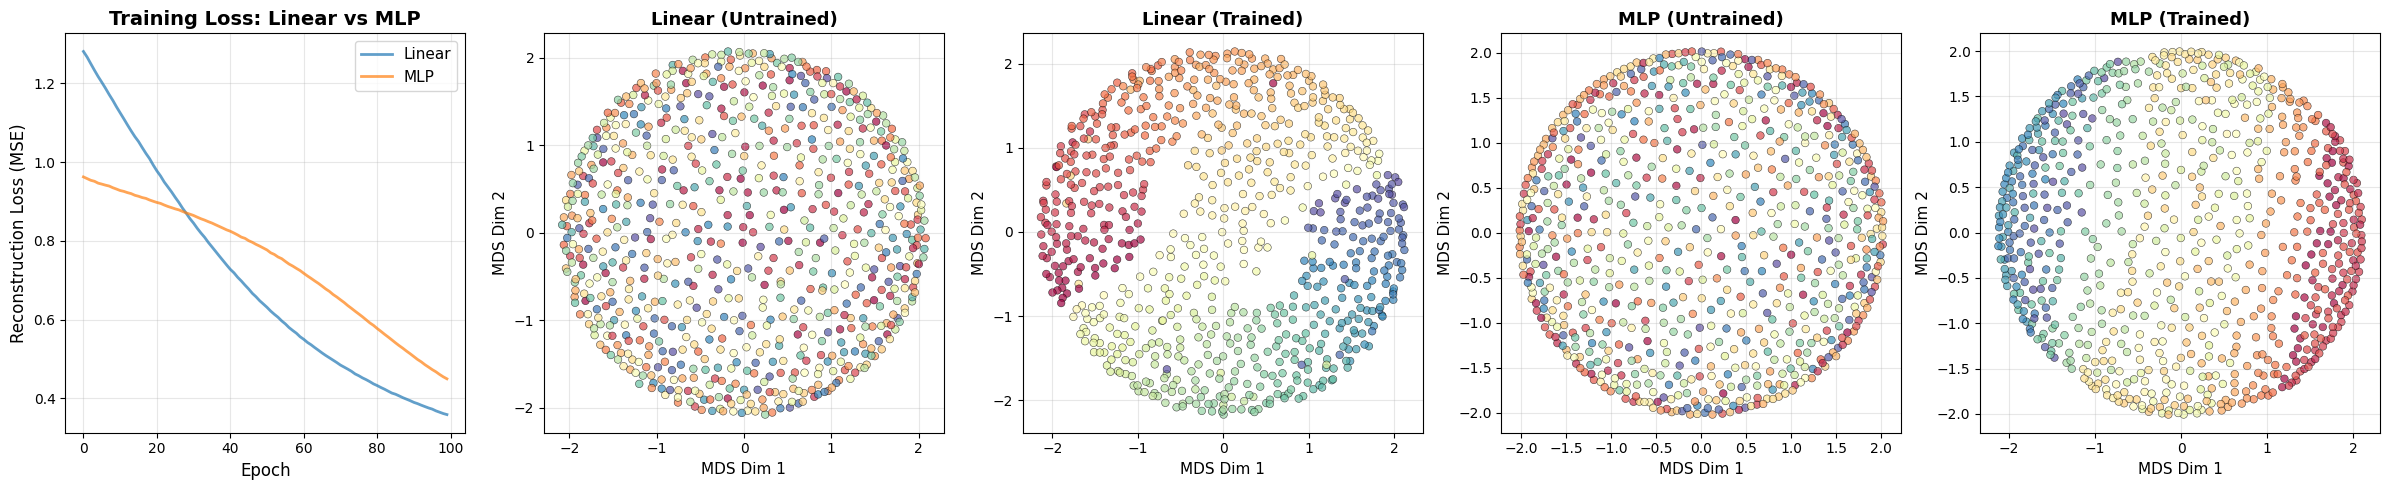

In [50]:
# Create comparison plot (trained vs untrained attention variants included)
fig = plt.figure(figsize=(26, 16))

# Plot original 3D data (TEST set)
ax = fig.add_subplot(3, 4, 1, projection='3d')
plot_3d(S_points_test, S_color_test, 'Original S-Curve (3D) - Test Set', ax)

# Plot sklearn methods 
sklearn_methods = ['PCA', 'LLE', 'Isomap', 'MDS', 'Spectral', 't-SNE', 'MDS', 'Spectral', 't-SNE']  
subplot_mapping = {method: idx for idx, method in zip(range(2, 8), sklearn_methods)}

for method_name, subplot_idx in subplot_mapping.items():
    if method_name in methods:
        ax = fig.add_subplot(3, 4, subplot_idx)
        color_array = S_color_test
        plot_2d(methods[method_name], color_array, method_name, ax)

# Plot attention methods (test set colors)
attention_plots = [
    ('Attention (Linear - Untrained)', 8),
    ('Attention (Linear - Trained)', 9),
    ('Attention (MLP - Untrained)', 10),
    ('Attention (MLP - Trained)', 11)
]
for title, subplot_idx in attention_plots:
    ax = fig.add_subplot(3, 4, subplot_idx)
    plot_2d(methods[title], S_color_test, title, ax)

plt.tight_layout()
plt.show()

# Plot training curves and trained vs untrained embeddings
plt.figure(figsize=(24, 5))

# Panel 1: Training curves
plt.subplot(1, 5, 1)
plt.plot(history_linear['losses'], label='Linear', alpha=0.7, linewidth=2)
plt.plot(history_mlp['losses'], label='MLP', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('Training Loss: Linear vs MLP', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Panel 2-5: Attention embeddings (test set)
plt.subplot(1, 5, 2)
plt.scatter(embedding_linear_untrained[:, 0], embedding_linear_untrained[:, 1], c=S_color_test, s=30, alpha=0.7, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.4)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('Linear (Untrained)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 3)
plt.scatter(embedding_linear_trained[:, 0], embedding_linear_trained[:, 1], c=S_color_test, s=30, alpha=0.7, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.4)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('Linear (Trained)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 4)
plt.scatter(embedding_mlp_untrained[:, 0], embedding_mlp_untrained[:, 1], c=S_color_test, s=30, alpha=0.7, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.4)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('MLP (Untrained)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 5)
plt.scatter(embedding_mlp_trained[:, 0], embedding_mlp_trained[:, 1], c=S_color_test, s=30, alpha=0.7, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.4)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('MLP (Trained)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Compare Linear vs MLP Projections

Let's test both linear and nonlinear (MLP) projections to see if MLP better approximates nonlinear manifold learning methods.


## Test on Swiss Roll Dataset

Let's test on another classic manifold learning dataset.


Swiss Roll dataset: (1500, 3)
Train set: (750, 3), Test set: (750, 3)

Swiss Roll: Testing Linear vs MLP Projections

Training Swiss Roll with LINEAR projections...
Epoch 10/100, Loss: 11.798538
Epoch 20/100, Loss: 10.632162
Epoch 30/100, Loss: 10.632711
Epoch 40/100, Loss: 10.631924
Epoch 50/100, Loss: 10.632350
Epoch 60/100, Loss: 10.633238
Epoch 70/100, Loss: 10.633168
Epoch 80/100, Loss: 10.633491
Epoch 90/100, Loss: 10.633857
Epoch 100/100, Loss: 10.633549

Training Swiss Roll with MLP projections...
Epoch 10/100, Loss: 3.000628
Epoch 20/100, Loss: 1.675638
Epoch 30/100, Loss: 1.155057
Epoch 40/100, Loss: 0.976308
Epoch 50/100, Loss: 0.880793
Epoch 60/100, Loss: 0.830393
Epoch 70/100, Loss: 0.793996
Epoch 80/100, Loss: 0.758320
Epoch 90/100, Loss: 0.695032
Epoch 100/100, Loss: 0.631184


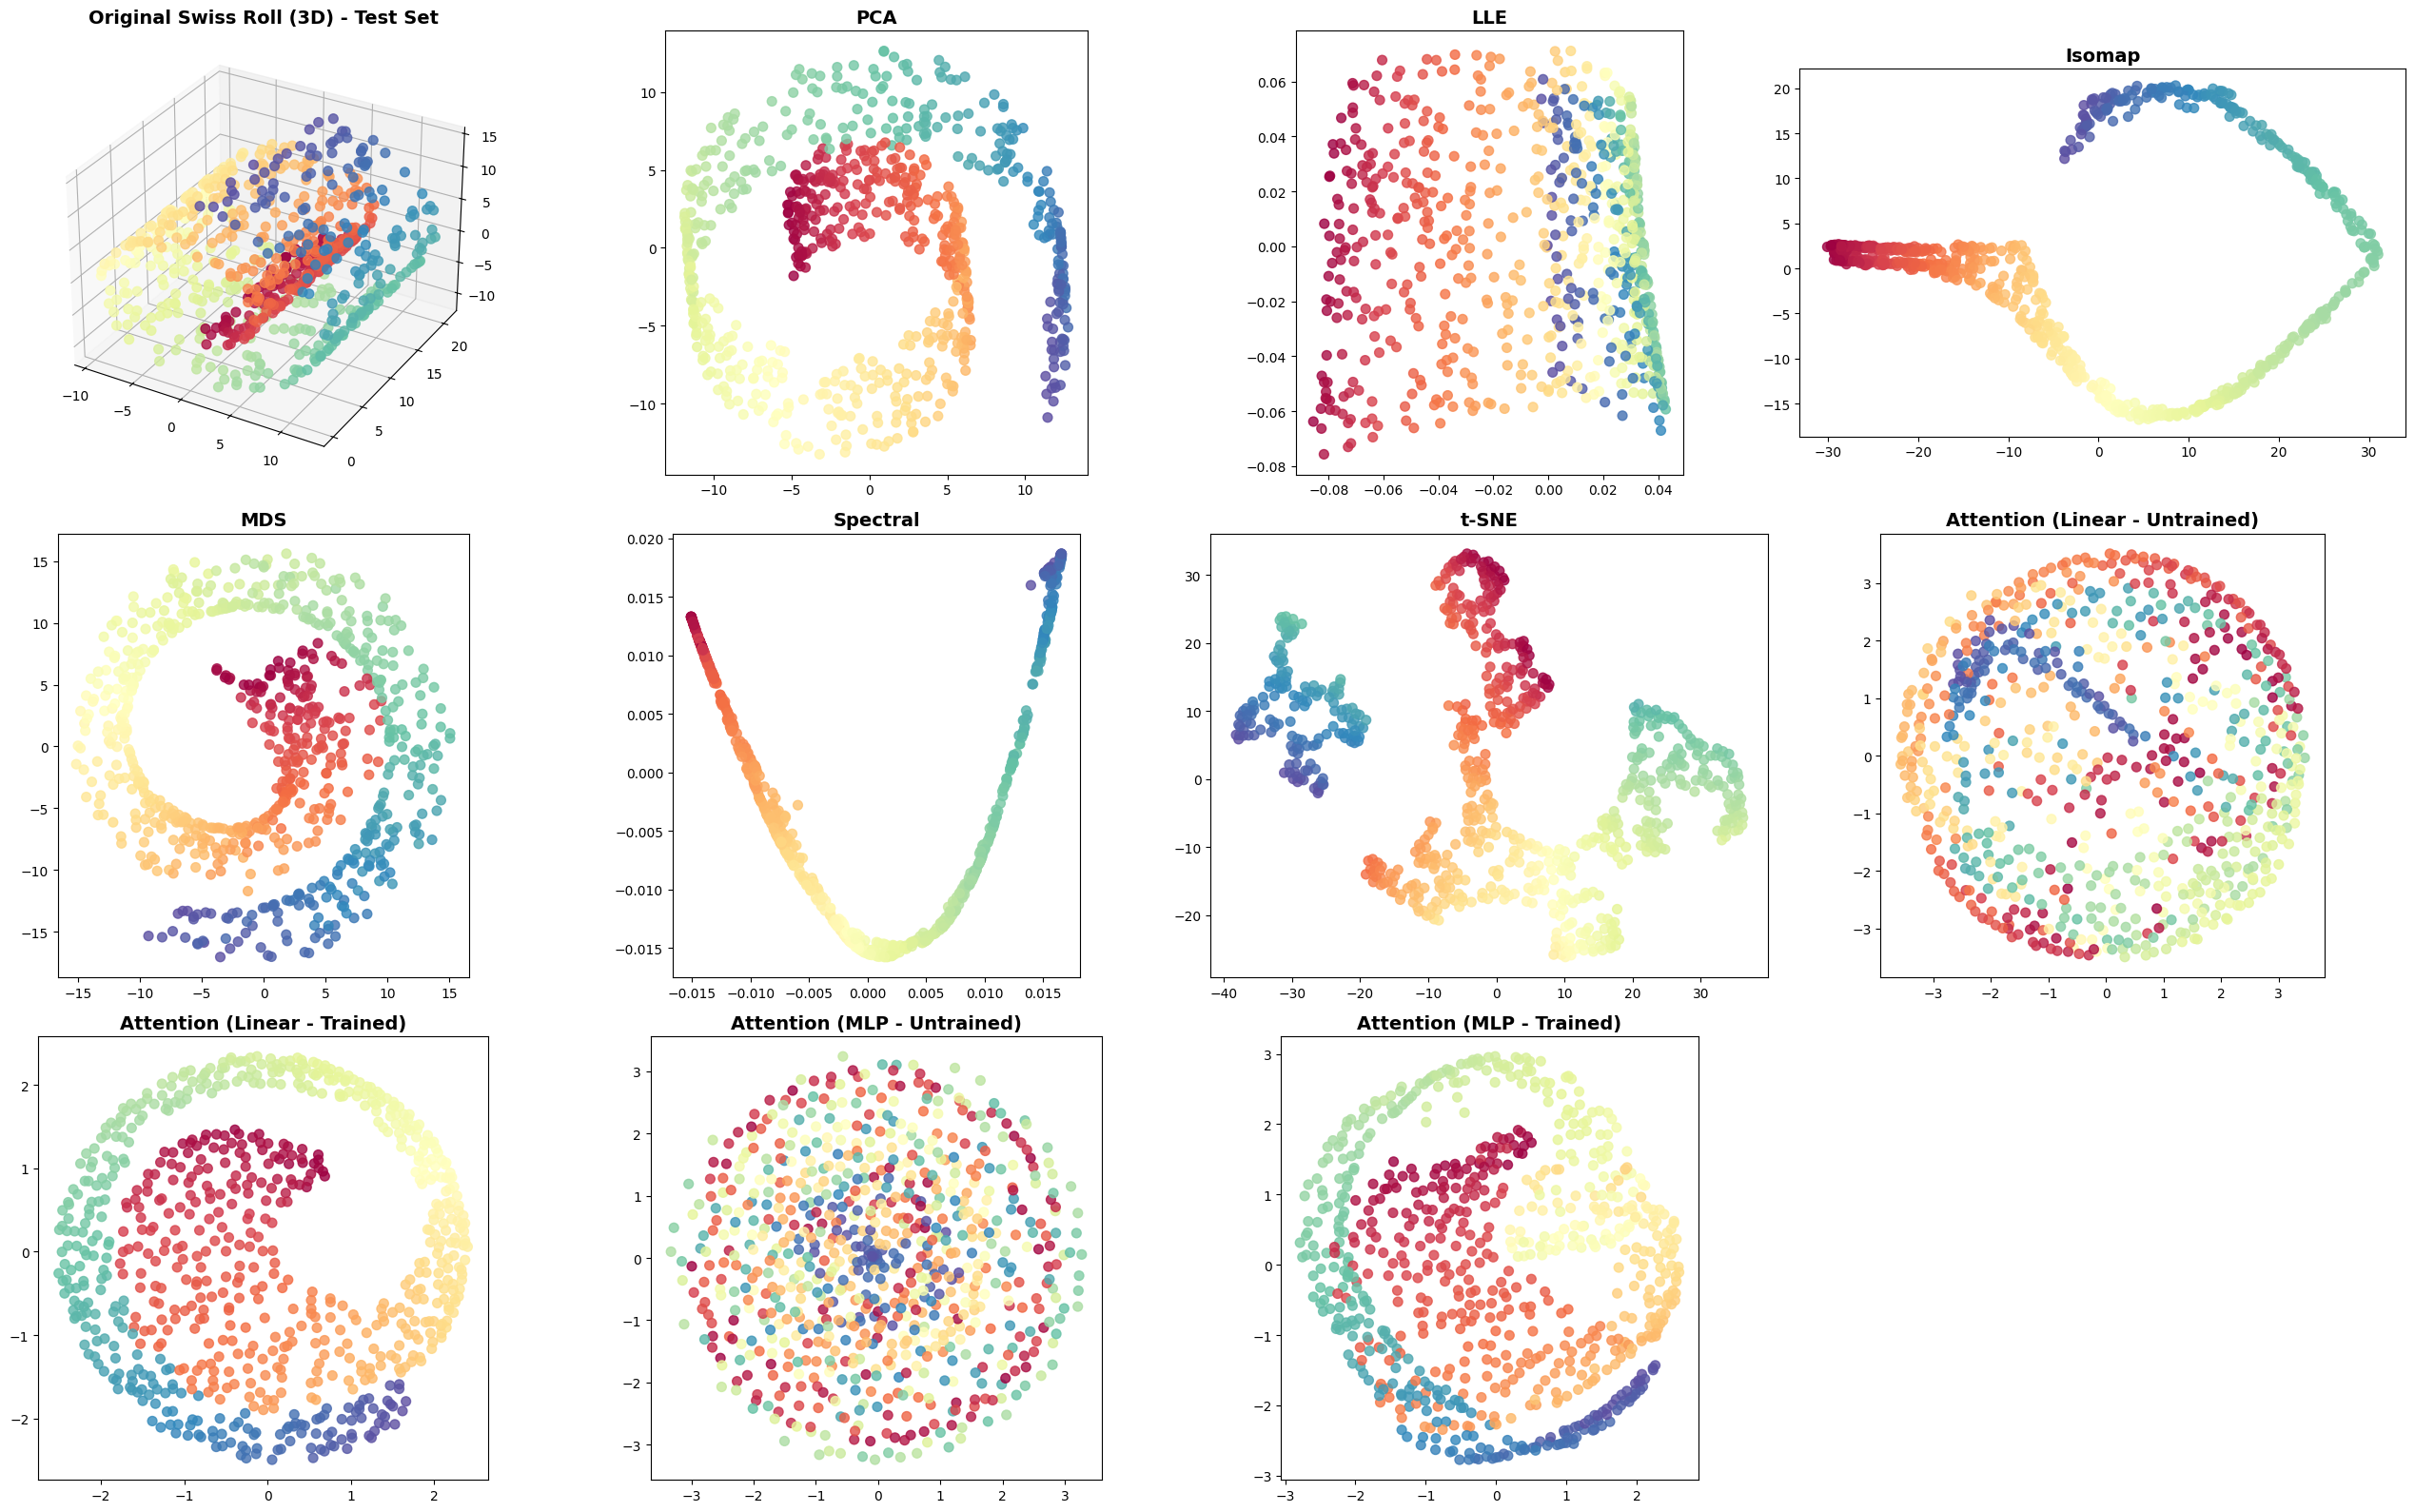

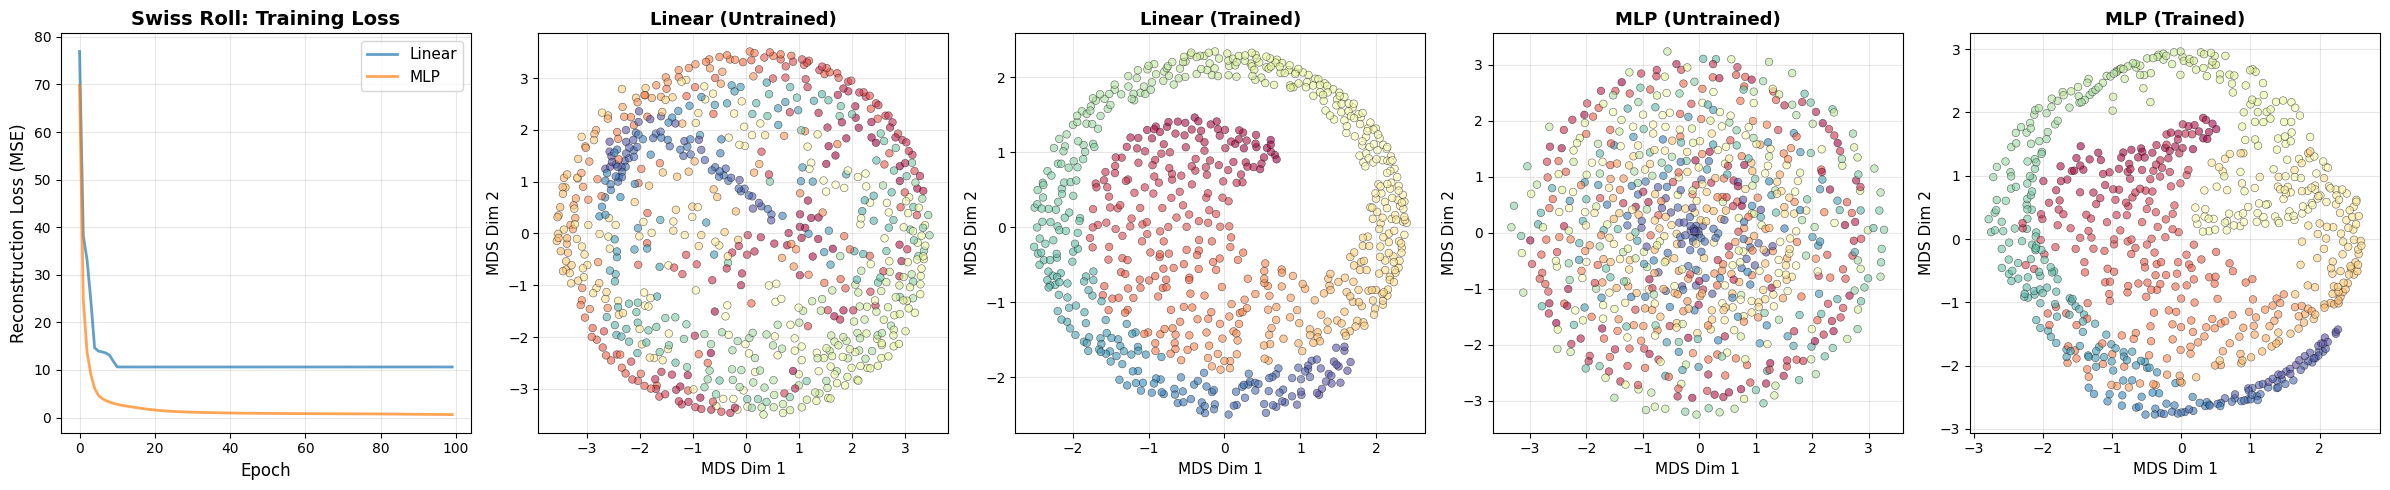

In [29]:
# Generate Swiss Roll dataset
swiss_points_full, swiss_color_full = datasets.make_swiss_roll(n_samples=1500, random_state=42)

# Split into train/test (50/50)
swiss_points_train, swiss_points_test, swiss_color_train, swiss_color_test = train_test_split(
    swiss_points_full, swiss_color_full, test_size=0.5, random_state=42
)

print(f"Swiss Roll dataset: {swiss_points_full.shape}")
print(f"Train set: {swiss_points_train.shape}, Test set: {swiss_points_test.shape}")

# Train on Swiss Roll with both linear and MLP
print("\n" + "="*80)
print("Swiss Roll: Testing Linear vs MLP Projections")
print("="*80)

swiss_dataset = ManifoldDataset(
    swiss_points_train,
    seq_len=CONFIG.get('seq_len', None),
    stride=CONFIG.get('stride', 1),
    num_chunks=CONFIG.get('num_chunks', 1)
)

# Linear
swiss_model_linear = SimpleSelfAttention(
    d_model=3,
    n_hidden=64,
    use_attention_scores=CONFIG['use_attention_scores'],
    use_mlp_projections=False
).to(device)
swiss_linear_init_state = copy.deepcopy(swiss_model_linear.state_dict())

print("\nTraining Swiss Roll with LINEAR projections...")
swiss_history_linear = train_attention_manifold(swiss_model_linear, swiss_dataset, CONFIG, device)
# Extract embedding on TEST set (trained)
swiss_embedding_linear_trained, _ = extract_attention_embedding(
    swiss_model_linear, swiss_points_test, device, n_samples=100
)
# Evaluate untrained baseline
swiss_model_linear_untrained = SimpleSelfAttention(
    d_model=3,
    n_hidden=64,
    use_attention_scores=CONFIG['use_attention_scores'],
    use_mlp_projections=False
).to(device)
swiss_model_linear_untrained.load_state_dict(swiss_linear_init_state)
swiss_embedding_linear_untrained, _ = extract_attention_embedding(
    swiss_model_linear_untrained, swiss_points_test, device, n_samples=100
)

# MLP
swiss_model_mlp = SimpleSelfAttention(
    d_model=3,
    n_hidden=64,
    use_attention_scores=CONFIG['use_attention_scores'],
    use_mlp_projections=True
).to(device)
swiss_mlp_init_state = copy.deepcopy(swiss_model_mlp.state_dict())

print("\nTraining Swiss Roll with MLP projections...")
swiss_history_mlp = train_attention_manifold(swiss_model_mlp, swiss_dataset, CONFIG, device)
# Extract embedding on TEST set (trained)
swiss_embedding_mlp_trained, _ = extract_attention_embedding(
    swiss_model_mlp, swiss_points_test, device, n_samples=100
)
# Evaluate untrained baseline
swiss_model_mlp_untrained = SimpleSelfAttention(
    d_model=3,
    n_hidden=64,
    use_attention_scores=CONFIG['use_attention_scores'],
    use_mlp_projections=True
).to(device)
swiss_model_mlp_untrained.load_state_dict(swiss_mlp_init_state)
swiss_embedding_mlp_untrained, _ = extract_attention_embedding(
    swiss_model_mlp_untrained, swiss_points_test, device, n_samples=100
)

# Apply other methods - fit on train, transform test
swiss_methods = {}
pca_swiss = PCA(n_components=2, random_state=42)
pca_swiss.fit(swiss_points_train)
swiss_methods['PCA'] = pca_swiss.transform(swiss_points_test)

lle_swiss = manifold.LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=42)
lle_swiss.fit(swiss_points_train)
swiss_methods['LLE'] = lle_swiss.transform(swiss_points_test)

isomap_swiss = manifold.Isomap(n_neighbors=12, n_components=2)
isomap_swiss.fit(swiss_points_train)
swiss_methods['Isomap'] = isomap_swiss.transform(swiss_points_test)

# MDS - doesn't have transform, use fit_transform on train
mds_swiss = manifold.MDS(n_components=2, random_state=42, normalized_stress=False)
swiss_methods['MDS'] = mds_swiss.fit_transform(swiss_points_train)  # Using train (MDS limitation)

# Spectral Embedding - doesn't have transform, use fit_transform on train
spectral_swiss = manifold.SpectralEmbedding(n_components=2, n_neighbors=12, random_state=42)
swiss_methods['Spectral'] = spectral_swiss.fit_transform(swiss_points_train)  # Using train (SpectralEmbedding limitation)

# t-SNE doesn't have transform, use train embedding
tsne_swiss = manifold.TSNE(n_components=2, perplexity=30, random_state=42, init='random')
swiss_methods['t-SNE'] = tsne_swiss.fit_transform(swiss_points_train)  # Using train (t-SNE limitation)
swiss_methods['Attention (Linear - Untrained)'] = swiss_embedding_linear_untrained
swiss_methods['Attention (Linear - Trained)'] = swiss_embedding_linear_trained
swiss_methods['Attention (MLP - Untrained)'] = swiss_embedding_mlp_untrained
swiss_methods['Attention (MLP - Trained)'] = swiss_embedding_mlp_trained

# Visualize (with attention methods on separate subplots)
fig = plt.figure(figsize=(26, 16))
ax = fig.add_subplot(3, 4, 1, projection='3d')
plot_3d(swiss_points_test, swiss_color_test, 'Original Swiss Roll (3D) - Test Set', ax)

# Plot sklearn methods - use appropriate color array based on train/test
swiss_sklearn_methods = ['PCA', 'LLE', 'Isomap', 'MDS', 'Spectral', 't-SNE']
swiss_train_set_methods = ['MDS', 'Spectral', 't-SNE']
subplot_mapping = {method: idx for idx, method in zip(range(2, 8), swiss_sklearn_methods)}

for method_name, subplot_idx in subplot_mapping.items():
    if method_name in swiss_methods:
        ax = fig.add_subplot(3, 4, subplot_idx)
        color_array = swiss_color_train if method_name in swiss_train_set_methods else swiss_color_test
        plot_2d(swiss_methods[method_name], color_array, method_name, ax)

# Plot attention methods (test set colors)
for title, subplot_idx in [
    ('Attention (Linear - Untrained)', 8),
    ('Attention (Linear - Trained)', 9),
    ('Attention (MLP - Untrained)', 10),
    ('Attention (MLP - Trained)', 11)
]:
    ax = fig.add_subplot(3, 4, subplot_idx)
    plot_2d(swiss_methods[title], swiss_color_test, title, ax)

plt.tight_layout()
plt.show()

# Plot training curves and embeddings
plt.figure(figsize=(24, 5))

plt.subplot(1, 5, 1)
plt.plot(swiss_history_linear['losses'], label='Linear', alpha=0.7, linewidth=2)
plt.plot(swiss_history_mlp['losses'], label='MLP', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('Swiss Roll: Training Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 2)
plt.scatter(swiss_embedding_linear_untrained[:, 0], swiss_embedding_linear_untrained[:, 1], c=swiss_color_test, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.4)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('Linear (Untrained)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 3)
plt.scatter(swiss_embedding_linear_trained[:, 0], swiss_embedding_linear_trained[:, 1], c=swiss_color_test, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.4)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('Linear (Trained)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 4)
plt.scatter(swiss_embedding_mlp_untrained[:, 0], swiss_embedding_mlp_untrained[:, 1], c=swiss_color_test, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.4)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('MLP (Untrained)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 5)
plt.scatter(swiss_embedding_mlp_trained[:, 0], swiss_embedding_mlp_trained[:, 1], c=swiss_color_test, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.4)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('MLP (Trained)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Test on MNIST/Digits Dataset (High-Dimensional)

Let's test on a higher-dimensional dataset: the digits dataset (64-dimensional, 8x8 pixel images). This is a more realistic test case for manifold learning, as referenced in the [sklearn documentation](https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html).


In [30]:
# Load digits dataset (64-dimensional)
from sklearn.datasets import load_digits

digits = load_digits(n_class=6)  # Use 6 classes for faster computation
digits_points_full = digits.data
digits_labels_full = digits.target

print(f"Digits dataset: {digits_points_full.shape}")
print(f"Number of classes: {len(np.unique(digits_labels_full))}")
print(f"Classes: {np.unique(digits_labels_full)}")

# Normalize to [0, 1] for better training
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
digits_points_scaled_full = scaler.fit_transform(digits_points_full)

# Split into train/test (50/50)
digits_points_train, digits_points_test, digits_labels_train, digits_labels_test = train_test_split(
    digits_points_scaled_full, digits_labels_full, test_size=0.5, random_state=42, stratify=digits_labels_full
)

print(f"\nTrain set: {digits_points_train.shape}, Test set: {digits_points_test.shape}")
print(f"Scaled data range: [{digits_points_scaled_full.min():.3f}, {digits_points_scaled_full.max():.3f}]")


Digits dataset: (1083, 64)
Number of classes: 6
Classes: [0 1 2 3 4 5]

Train set: (541, 64), Test set: (542, 64)
Scaled data range: [0.000, 1.000]


In [31]:
# Train on Digits with both linear and MLP
print("\n" + "="*80)
print("Digits Dataset: Testing Linear vs MLP Projections")
print("="*80)

# Configuration for digits (64-dimensional)
CONFIG_DIGITS = {
    'd_model': 64,
    'n_hidden': 128,
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 150,
    'use_attention_scores': False,
    'use_mlp_projections': False,
    'loss_type': 'mse',
    'attn_dropout': 0.05,
    'num_chunks': 1000
}

digits_dataset = ManifoldDataset(
    digits_points_train,
    seq_len=CONFIG_DIGITS.get('seq_len', None),
    stride=CONFIG_DIGITS.get('stride', 1),
    num_chunks=CONFIG_DIGITS.get('num_chunks', 1)
)

# Linear
digits_model_linear = SimpleSelfAttention(
    d_model=CONFIG_DIGITS['d_model'],
    n_hidden=CONFIG_DIGITS['n_hidden'],
    use_attention_scores=CONFIG_DIGITS['use_attention_scores'],
    use_mlp_projections=False
).to(device)
digits_linear_init_state = copy.deepcopy(digits_model_linear.state_dict())

print(f"\nLinear model parameters: {sum(p.numel() for p in digits_model_linear.parameters()):,}")
print("\nTraining Digits with LINEAR projections...")
digits_history_linear = train_attention_manifold(digits_model_linear, digits_dataset, CONFIG_DIGITS, device)
# Extract embedding on TEST set (trained)
digits_embedding_linear_trained, _ = extract_attention_embedding(
    digits_model_linear, digits_points_test, device, n_samples=100
)
# Untrained baseline
digits_model_linear_untrained = SimpleSelfAttention(
    d_model=CONFIG_DIGITS['d_model'],
    n_hidden=CONFIG_DIGITS['n_hidden'],
    use_attention_scores=CONFIG_DIGITS['use_attention_scores'],
    use_mlp_projections=False
).to(device)
digits_model_linear_untrained.load_state_dict(digits_linear_init_state)
digits_embedding_linear_untrained, _ = extract_attention_embedding(
    digits_model_linear_untrained, digits_points_test, device, n_samples=100
)

# MLP
digits_model_mlp = SimpleSelfAttention(
    d_model=CONFIG_DIGITS['d_model'],
    n_hidden=CONFIG_DIGITS['n_hidden'],
    use_attention_scores=CONFIG_DIGITS['use_attention_scores'],
    use_mlp_projections=True
).to(device)
digits_mlp_init_state = copy.deepcopy(digits_model_mlp.state_dict())

print(f"\nMLP model parameters: {sum(p.numel() for p in digits_model_mlp.parameters()):,}")
print("\nTraining Digits with MLP projections...")
digits_history_mlp = train_attention_manifold(digits_model_mlp, digits_dataset, CONFIG_DIGITS, device)
# Extract embedding on TEST set (trained)
digits_embedding_mlp_trained, _ = extract_attention_embedding(
    digits_model_mlp, digits_points_test, device, n_samples=100
)
# Untrained baseline
digits_model_mlp_untrained = SimpleSelfAttention(
    d_model=CONFIG_DIGITS['d_model'],
    n_hidden=CONFIG_DIGITS['n_hidden'],
    use_attention_scores=CONFIG_DIGITS['use_attention_scores'],
    use_mlp_projections=True
).to(device)
digits_model_mlp_untrained.load_state_dict(digits_mlp_init_state)
digits_embedding_mlp_untrained, _ = extract_attention_embedding(
    digits_model_mlp_untrained, digits_points_test, device, n_samples=100
)



Digits Dataset: Testing Linear vs MLP Projections

Linear model parameters: 16,384

Training Digits with LINEAR projections...
Epoch 10/150, Loss: 0.023045
Epoch 20/150, Loss: 0.017262
Epoch 30/150, Loss: 0.015007
Epoch 40/150, Loss: 0.013961
Epoch 50/150, Loss: 0.013376
Epoch 60/150, Loss: 0.012971
Epoch 70/150, Loss: 0.012646
Epoch 80/150, Loss: 0.012375
Epoch 90/150, Loss: 0.012143
Epoch 100/150, Loss: 0.011938
Epoch 110/150, Loss: 0.011753
Epoch 120/150, Loss: 0.011585
Epoch 130/150, Loss: 0.011437
Epoch 140/150, Loss: 0.011302
Epoch 150/150, Loss: 0.011185

MLP model parameters: 49,664

Training Digits with MLP projections...
Epoch 10/150, Loss: 0.017372
Epoch 20/150, Loss: 0.012880
Epoch 30/150, Loss: 0.012142
Epoch 40/150, Loss: 0.011746
Epoch 50/150, Loss: 0.011492
Epoch 60/150, Loss: 0.011304
Epoch 70/150, Loss: 0.011161
Epoch 80/150, Loss: 0.011046
Epoch 90/150, Loss: 0.010950
Epoch 100/150, Loss: 0.010853
Epoch 110/150, Loss: 0.010793
Epoch 120/150, Loss: 0.010721
Epoch 130

In [32]:
# Apply sklearn methods to digits - fit on train, transform test
print("\nApplying sklearn manifold learning methods to digits (fit on train, transform test)...")
digits_methods = {}

# PCA - fit on train, transform test
pca_digits = PCA(n_components=2, random_state=42)
pca_digits.fit(digits_points_train)
digits_methods['PCA'] = pca_digits.transform(digits_points_test)

# LLE - fit on train, transform test
lle_digits = manifold.LocallyLinearEmbedding(
    n_neighbors=30, n_components=2, random_state=42
)
lle_digits.fit(digits_points_train)
digits_methods['LLE'] = lle_digits.transform(digits_points_test)

# Isomap - fit on train, transform test
isomap_digits = manifold.Isomap(n_neighbors=30, n_components=2)
isomap_digits.fit(digits_points_train)
digits_methods['Isomap'] = isomap_digits.transform(digits_points_test)

# MDS - doesn't have transform, use fit_transform on train
mds_digits = manifold.MDS(n_components=2, random_state=42, normalized_stress=False)
digits_methods['MDS'] = mds_digits.fit_transform(digits_points_train)  # Using train (MDS limitation)

# Spectral Embedding - doesn't have transform, use fit_transform on train
spectral_digits = manifold.SpectralEmbedding(
    n_components=2, n_neighbors=30, random_state=42
)
digits_methods['Spectral'] = spectral_digits.fit_transform(digits_points_train)  # Using train (SpectralEmbedding limitation)

# t-SNE (may take longer) - doesn't have transform, use train embedding
print("Computing t-SNE (this may take a while)...")
tsne_digits = manifold.TSNE(
    n_components=2, perplexity=30, random_state=42, init='random'
)
digits_methods['t-SNE'] = tsne_digits.fit_transform(digits_points_train)  # Using train (t-SNE limitation)

# Add attention methods (trained vs untrained)
digits_methods['Attention (Linear - Untrained)'] = digits_embedding_linear_untrained
digits_methods['Attention (Linear - Trained)'] = digits_embedding_linear_trained
digits_methods['Attention (MLP - Untrained)'] = digits_embedding_mlp_untrained
digits_methods['Attention (MLP - Trained)'] = digits_embedding_mlp_trained

print(f"\nApplied {len(digits_methods)} methods to digits dataset")



Applying sklearn manifold learning methods to digits (fit on train, transform test)...
Computing t-SNE (this may take a while)...

Applied 10 methods to digits dataset


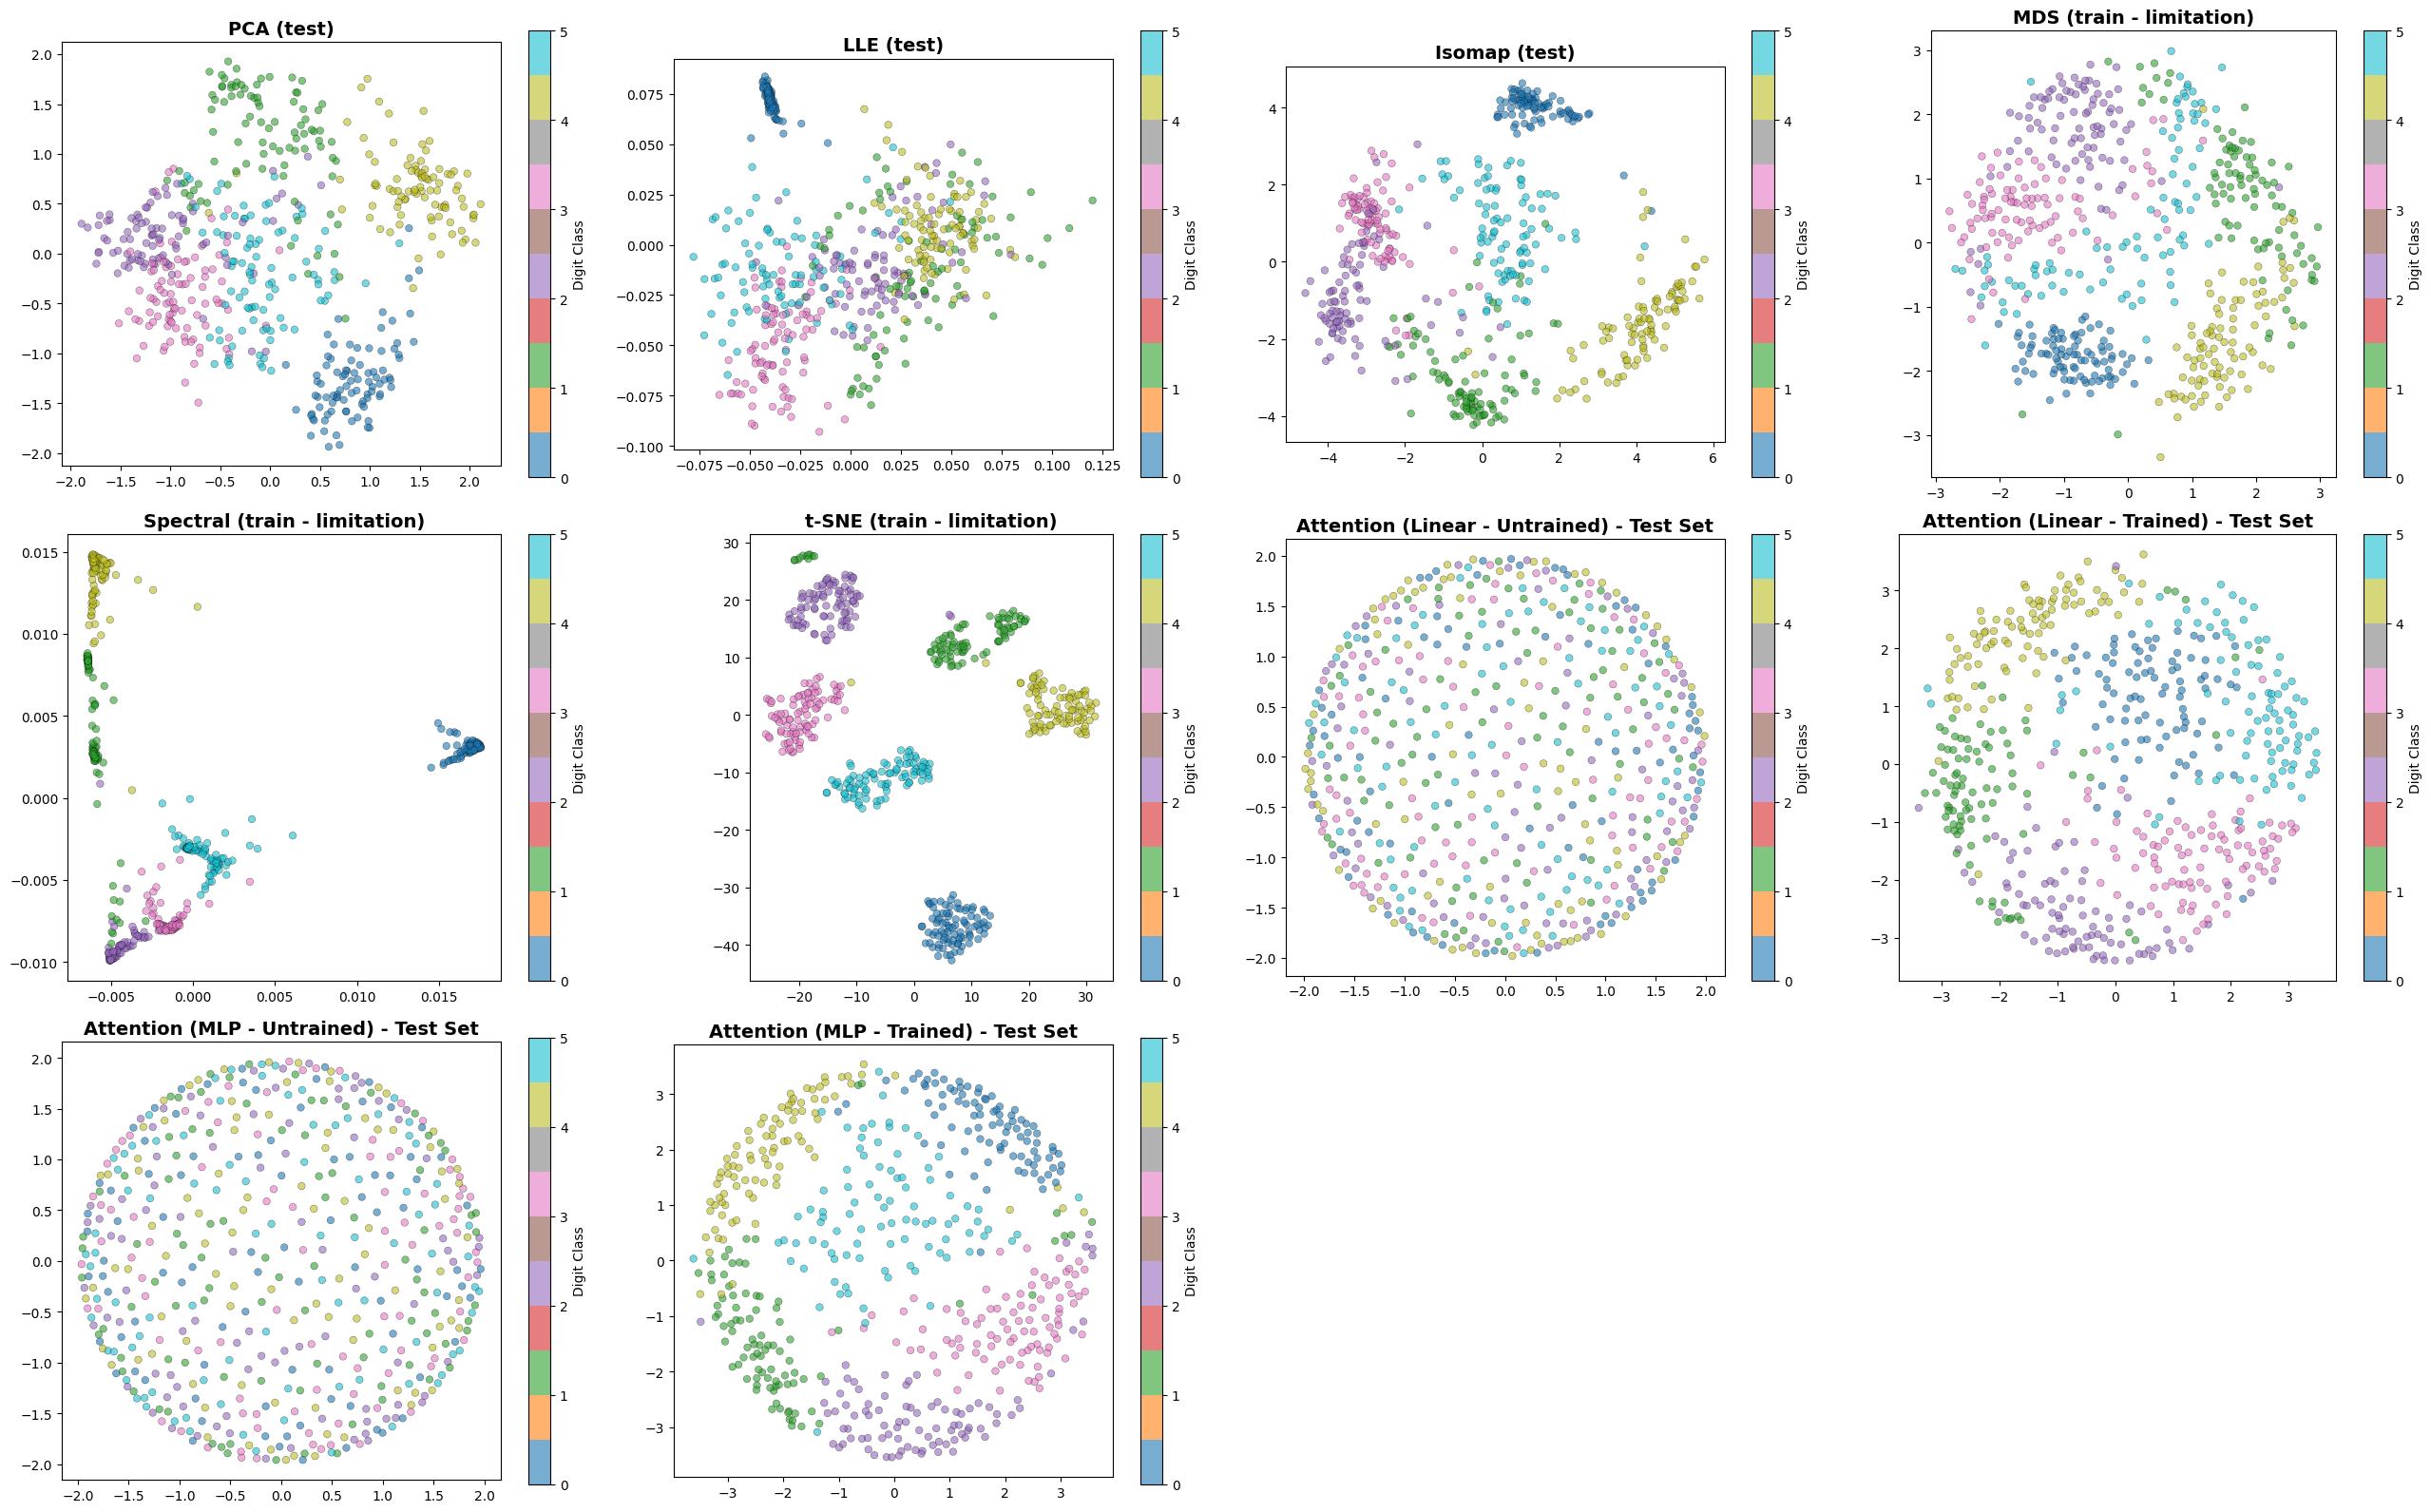

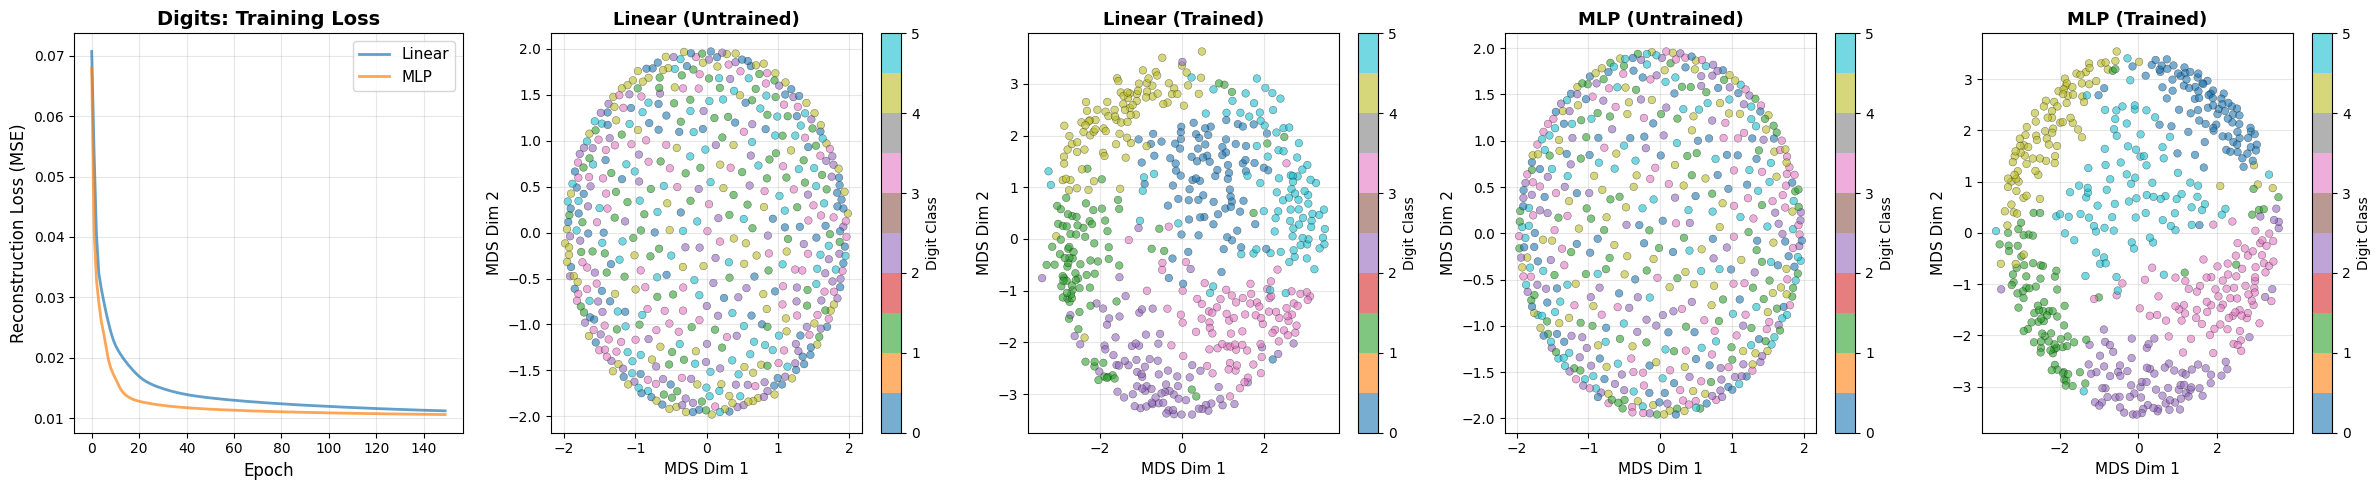

In [33]:
# Visualize digits embeddings (trained vs untrained attention baselines)
digits_sklearn_methods = ['PCA', 'LLE', 'Isomap', 'MDS', 'Spectral', 't-SNE']
digits_train_set_methods = ['MDS', 'Spectral', 't-SNE']

fig, axes = plt.subplots(3, 4, figsize=(26, 16))
axes = axes.flatten()

# Plot sklearn methods
for idx, method_name in enumerate(digits_sklearn_methods):
    ax = axes[idx]
    label_array = digits_labels_train if method_name in digits_train_set_methods else digits_labels_test
    scatter = ax.scatter(
        digits_methods[method_name][:, 0],
        digits_methods[method_name][:, 1],
        c=label_array,
        s=30,
        alpha=0.6,
        cmap=plt.cm.tab10,
        edgecolors='black',
        linewidths=0.3
    )
    title_suffix = " (train - limitation)" if method_name in digits_train_set_methods else " (test)"
    ax.set_title(f"{method_name}{title_suffix}", size=14, fontweight='bold')
    ax.set_aspect('equal')
    fig.colorbar(scatter, ax=ax, label='Digit Class')

# Plot attention methods on remaining subplots
attention_entries = [
    ('Attention (Linear - Untrained)', digits_labels_test),
    ('Attention (Linear - Trained)', digits_labels_test),
    ('Attention (MLP - Untrained)', digits_labels_test),
    ('Attention (MLP - Trained)', digits_labels_test)
]
for offset, (title, labels) in enumerate(attention_entries, start=len(digits_sklearn_methods)):
    ax = axes[offset]
    scatter = ax.scatter(
        digits_methods[title][:, 0],
        digits_methods[title][:, 1],
        c=labels,
        s=30,
        alpha=0.6,
        cmap=plt.cm.tab10,
        edgecolors='black',
        linewidths=0.3
    )
    ax.set_title(f"{title} - Test Set", size=14, fontweight='bold')
    ax.set_aspect('equal')
    fig.colorbar(scatter, ax=ax, label='Digit Class')

# Remove any unused axes
for idx in range(len(digits_sklearn_methods) + len(attention_entries), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Plot training curves and embeddings (trained vs untrained)
plt.figure(figsize=(24, 5))

plt.subplot(1, 5, 1)
plt.plot(digits_history_linear['losses'], label='Linear', alpha=0.7, linewidth=2)
plt.plot(digits_history_mlp['losses'], label='MLP', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('Digits: Training Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 2)
scatter = plt.scatter(
    digits_embedding_linear_untrained[:, 0], digits_embedding_linear_untrained[:, 1],
    c=digits_labels_test, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('Linear (Untrained)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Digit Class')
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 3)
scatter = plt.scatter(
    digits_embedding_linear_trained[:, 0], digits_embedding_linear_trained[:, 1],
    c=digits_labels_test, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('Linear (Trained)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Digit Class')
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 4)
scatter = plt.scatter(
    digits_embedding_mlp_untrained[:, 0], digits_embedding_mlp_untrained[:, 1],
    c=digits_labels_test, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('MLP (Untrained)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Digit Class')
plt.grid(True, alpha=0.3)

plt.subplot(1, 5, 5)
scatter = plt.scatter(
    digits_embedding_mlp_trained[:, 0], digits_embedding_mlp_trained[:, 1],
    c=digits_labels_test, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
plt.xlabel('MDS Dim 1', fontsize=11)
plt.ylabel('MDS Dim 2', fontsize=11)
plt.title('MLP (Trained)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Digit Class')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Analysis: Are Results Too Good to Be True?

Let's verify that our attention-based method is actually learning meaningful structure by:
1. Checking reconstruction quality
2. Comparing attention matrices between linear and MLP
3. Analyzing whether the embeddings preserve class structure


In [34]:
# Verify reconstruction quality and attention patterns
print("="*80)
print("Verification Analysis")
print("="*80)

# Check reconstruction error on test data
def check_reconstruction_quality(model, X, device, name):
    """Check how well the model reconstructs the input."""
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(X_tensor)
        recon = out['output'].cpu().numpy()[0]
        mse = np.mean((X - recon) ** 2)
        mae = np.mean(np.abs(X - recon))
    
    print(f"\n{name} Reconstruction Quality:")
    print(f"  MSE: {mse:.6f}")
    print(f"  MAE: {mae:.6f}")
    print(f"  Relative Error: {mae / (np.abs(X).mean() + 1e-9):.4%}")
    return mse, mae

# Check for S-curve (TEST set)
print("\n--- S-Curve Dataset (Test Set) ---")
mse_linear, mae_linear = check_reconstruction_quality(model_linear, S_points_test, device, "Linear")
mse_mlp, mae_mlp = check_reconstruction_quality(model_mlp, S_points_test, device, "MLP")

# Check for digits (TEST set)
print("\n--- Digits Dataset (Test Set) ---")
mse_digits_linear, mae_digits_linear = check_reconstruction_quality(
    digits_model_linear, digits_points_test, device, "Linear"
)
mse_digits_mlp, mae_digits_mlp = check_reconstruction_quality(
    digits_model_mlp, digits_points_test, device, "MLP"
)

# Check if embeddings preserve class structure (for digits - TEST set)
from sklearn.metrics import silhouette_score

print("\n--- Class Separation Analysis (Digits - Test Set) ---")
for method_name, embedding in digits_methods.items():
    # Handle methods that use train set (MDS, SpectralEmbedding, and t-SNE don't have transform)
    if method_name in ['t-SNE', 'MDS', 'Spectral']:
        # Use train labels for these methods since they're trained on train
        if embedding.shape[0] == len(digits_labels_train):
            sil_score = silhouette_score(embedding, digits_labels_train)
            print(f"{method_name:20s}: Silhouette Score = {sil_score:.4f} (train set - {method_name} limitation)")
    else:
        # All other methods use test set
        if embedding.shape[0] == len(digits_labels_test):
            sil_score = silhouette_score(embedding, digits_labels_test)
            print(f"{method_name:20s}: Silhouette Score = {sil_score:.4f}")


Verification Analysis

--- S-Curve Dataset (Test Set) ---

Linear Reconstruction Quality:
  MSE: 0.102082
  MAE: 0.226638
  Relative Error: 23.6774%

MLP Reconstruction Quality:
  MSE: 0.014392
  MAE: 0.100371
  Relative Error: 10.4860%

--- Digits Dataset (Test Set) ---

Linear Reconstruction Quality:
  MSE: 0.018445
  MAE: 0.076857
  Relative Error: 25.0365%

MLP Reconstruction Quality:
  MSE: 0.024895
  MAE: 0.086346
  Relative Error: 28.1274%

--- Class Separation Analysis (Digits - Test Set) ---
PCA                 : Silhouette Score = 0.3283
LLE                 : Silhouette Score = 0.2173
Isomap              : Silhouette Score = 0.4527
MDS                 : Silhouette Score = 0.2779 (train set - MDS limitation)
Spectral            : Silhouette Score = 0.6393 (train set - Spectral limitation)
t-SNE               : Silhouette Score = 0.6275 (train set - t-SNE limitation)
Attention (Linear - Untrained): Silhouette Score = -0.0675
Attention (Linear - Trained): Silhouette Score = 0.25